In [1]:
# Imports
import warnings

import pandas as pd

from src.reading_data import create_final_dfs
from src.visualizations import *
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)
os.makedirs("../../doc/figs", exist_ok=True)
apply_paper_style()

In [58]:
# Load data
df_all_raw, df_all, df_A, df_B, _, df_metadata, _ = create_final_dfs()


Models excluded (< 200 valid responses), 17 total:
                                       n_valid
model                                         
ThingAI/Quark-270m-Base                      0
google/gemma-3-270m                         14
google/gemma-3-270m-it                      16
EssentialAI/rnj-1                           63
google/gemma-4-31B                          81
Qwen/Qwen3-0.6B                             93
Qwen/Qwen3.5-0.8B-Base                      99
google/gemma-3-1b-pt                       112
ThingAI/Quark-270m-Instruct                121
google/gemma-3-1b-it                       122
google/gemma-2b                            157
mistralai/Mistral-Small-24B-Base-2501      163
Qwen/Qwen3.5-4B-Base                       174
tiiuae/Falcon3-1B-Base                     178
Qwen/Qwen3.5-2B-Base                       192
allenai/OLMo-2-0425-1B                     197
google/gemma-2-2b                          198

Models present before exclusion: 264
Models remaining 

In [3]:
# get in column "usage"
import ast

def extract_cost(x):
    if pd.isna(x):
        return 0
    try:
        return ast.literal_eval(x).get("response_costs", 0)
    except (ValueError, SyntaxError, AttributeError):
        return 0

df_all["cost"] = df_all["usage"].apply(extract_cost)
df_all["cost"] = pd.to_numeric(df_all["cost"], errors="coerce").fillna(0)

df_all

,prompt,model,inventory,situation,rep,item,preamble,postamble,options,timestamp,response,usage,reasoning,dimension,key,score,cost
0,Here is a characteristic that may or may not a...,openrouter/moonshotai/kimi-k2-thinking,bfi-llm,baseline,0,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260508,1.0,"{'total_tokens': 1127, 'prompt_tokens': 134, '...",The user is asking me to rate a statement abou...,Neuroticism,+,1.0,0.002563
1,Here is a characteristic that may or may not a...,openrouter/moonshotai/kimi-k2-thinking,bfi-llm,baseline,1,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260508,2.0,"{'total_tokens': 626, 'prompt_tokens': 134, 'c...",The prompt asks me to rate a statement about m...,Neuroticism,+,2.0,0.001310
2,Here is a characteristic that may or may not a...,openrouter/moonshotai/kimi-k2-thinking,bfi-llm,baseline,2,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260508,1.0,"{'total_tokens': 813, 'prompt_tokens': 134, 'c...",The user is asking me to rate a statement abou...,Neuroticism,+,1.0,0.001778
3,Here is a characteristic that may or may not a...,openrouter/moonshotai/kimi-k2-thinking,bfi-llm,baseline,3,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260508,1.0,"{'total_tokens': 394, 'prompt_tokens': 134, 'c...",The user is asking me to rate a statement abou...,Neuroticism,+,1.0,0.000730
4,Here is a characteristic that may or may not a...,openrouter/moonshotai/kimi-k2-thinking,bfi-llm,baseline,4,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260508,1.0,"{'total_tokens': 708, 'prompt_tokens': 134, 'c...",The user is asking me to rate a statement abou...,Neuroticism,+,1.0,0.001515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155595,Here is a characteristic that may or may not a...,openrouter/mistralai/mistral-7b-instruct-v0.1,bfi-llm,baseline,0,uses imaginative examples,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n5 = Agree strongly\n4 = Agree a little\n3 = ...,20260508,3.0,"{'total_tokens': 198, 'prompt_tokens': 140, 'c...",,Openness,+,3.0,0.000026
155596,Here is a characteristic that may or may not a...,openrouter/mistralai/mistral-7b-instruct-v0.1,bfi-llm,baseline,1,uses imaginative examples,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n5 = Agree strongly\n4 = Agree a little\n3 = ...,20260508,3.0,"{'total_tokens': 196, 'prompt_tokens': 140, 'c...",,Openness,+,3.0,0.000026
155597,Here is a characteristic that may or may not a...,openrouter/mistralai/mistral-7b-instruct-v0.1,bfi-llm,baseline,2,uses imaginative examples,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n5 = Agree strongly\n4 = Agree a little\n3 = ...,20260508,3.0,"{'total_tokens': 196, 'prompt_tokens': 140, 'c...",,Openness,+,3.0,0.000026
155598,Here is a characteristic that may or may not a...,openrouter/mistralai/mistral-7b-instruct-v0.1,bfi-llm,baseline,3,uses imaginative examples,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n5 = Agree strongly\n4 = Agree a little\n3 = ...,20260508,3.0,"{'total_tokens': 196, 'prompt_tokens': 140, 'c...",,Openness,+

In [4]:
avg_cost_by_model = (
    df_all.groupby("model", as_index=False)["cost"]
    .mean()
    .rename(columns={"cost": "avg_cost"})
)
avg_cost_by_model

,model,avg_cost
0,Qwen/Qwen3-0.6B-Base,0.000000
1,Qwen/Qwen3-14B-Base,0.000000
2,Qwen/Qwen3-30B-A3B-Base,0.000000
3,Qwen/Qwen3-8B-Base,0.000000
4,Qwen/Qwen3.5-35B-A3B-Base,0.000000
...,...,...
242,xai/grok-4-1-fast-non-reasoning,0.000019
243,xai/grok-4-1-fast-reasoning,0.000158
244,xai/grok-4-fast,0.000113
245,xai/grok-4.20,0.004615


In [5]:
cost_by_model = (
    df_all.groupby("model")["cost"]
    .agg(avg_cost="mean", total_cost="sum")
    .reset_index()
)
cost_by_model

,model,avg_cost,total_cost
0,Qwen/Qwen3-0.6B-Base,0.000000,0.000000
1,Qwen/Qwen3-14B-Base,0.000000,0.000000
2,Qwen/Qwen3-30B-A3B-Base,0.000000,0.000000
3,Qwen/Qwen3-8B-Base,0.000000,0.000000
4,Qwen/Qwen3.5-35B-A3B-Base,0.000000,0.000000
...,...,...,...
242,xai/grok-4-1-fast-non-reasoning,0.000019,0.008435
243,xai/grok-4-1-fast-reasoning,0.000158,0.069594
244,xai/grok-4-fast,0.000113,0.049512
245,xai/grok-4.20,0.004615,2.030470


In [6]:
budget = pd.read_excel(
    "../../dat/03_large_scale_administration/budget.xlsx",)

cost_by_model = cost_by_model.merge(budget[["model", "estimated_cost"]], on="model", how="left")
cost_by_model["cost_diff"] = cost_by_model["estimated_cost"] - cost_by_model["total_cost"]
cost_by_model.to_csv("../../dat/03_large_scale_administration/cost_by_model.csv")

In [7]:
df_all[["model", "item", "response", "reasoning", "dimension"]]

,model,item,response,reasoning,dimension
0,openrouter/moonshotai/kimi-k2-thinking,becomes hesitant or erratic when faced with di...,1.0,The user is asking me to rate a statement abou...,Neuroticism
1,openrouter/moonshotai/kimi-k2-thinking,becomes hesitant or erratic when faced with di...,2.0,The prompt asks me to rate a statement about m...,Neuroticism
2,openrouter/moonshotai/kimi-k2-thinking,becomes hesitant or erratic when faced with di...,1.0,The user is asking me to rate a statement abou...,Neuroticism
3,openrouter/moonshotai/kimi-k2-thinking,becomes hesitant or erratic when faced with di...,1.0,The user is asking me to rate a statement abou...,Neuroticism
4,openrouter/moonshotai/kimi-k2-thinking,becomes hesitant or erratic when faced with di...,1.0,The user is asking me to rate a statement abou...,Neuroticism
...,...,...,...,...,...
155595,openrouter/mistralai/mistral-7b-instruct-v0.1,uses imaginative examples,3.0,,Openness
155596,openrouter/mistralai/mistral-7b-instruct-v0.1,uses imaginative examples,3.0,,Openness
155597,openrouter/mistralai/mistral-7b-instruct-v0.1,uses imaginative examples,3.0,,Openness
155598,openrouter/mistralai/mistral-7b-instruct-v0.1,uses imaginative examples,3.0,,Openness


In [8]:
# for models that have column "reasoning" not empty, groupby model and take first row
df_reasoning = df_all[df_all["reasoning"].notnull()].groupby("model").first()
df_reasoning = df_reasoning[df_reasoning["reasoning"] != ""]

In [9]:
df_reasoning

,prompt,inventory,situation,rep,item,preamble,postamble,options,timestamp,response,usage,reasoning,dimension,key,score,cost
model,,,,,,,,,,,,,,,,
Qwen/Qwen3-0.6B-Base,\n ### TASK\n Here is a ...,bfi-llm,baseline,0,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260518,5.0,None,"{\n ""score"": 1,\n ""response"": ""0"",\n}\n\n ...",Neuroticism,+,5.0,0.000000
Qwen/Qwen3-14B-Base,\n ### TASK\n Here is a ...,bfi-llm,baseline,0,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260717,1.0,None,"To complete the task, I will follow these step...",Neuroticism,+,1.0,0.000000
Qwen/Qwen3-30B-A3B-Base,\n ### TASK\n Here is a ...,bfi-llm,baseline,0,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260717,1.0,None,'''\n output2 = '''\n \n...,Neuroticism,+,1.0,0.000000
Qwen/Qwen3-8B-Base,\n ### TASK\n Here is a ...,bfi-llm,baseline,0,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260518,4.0,None,"[\n {\n ""role"": ""system"",\n ""content"": ...",Neuroticism,+,4.0,0.000000
Qwen/Qwen3.5-35B-A3B-Base,\n ### TASK\n Here is a ...,bfi-llm,baseline,0,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260717,1.0,None,Here is the answer to be filled:\n\n ...,Neuroticism,+,1.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tiiuae/Falcon3-3B-Base,\n ### TASK\n Here is a ...,bfi-llm,baseline,0,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260602,3.0,None,"[\n {\n ""score"": 4,\n ""re...",Neuroticism,+,3.0,0.000000
tiiuae/Falcon3-3B-Instruct,\n ### TASK\n Here is a ...,bfi-llm,baseline,0,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260602,4.0,None,"<|assistant|>\n {""score"": 4, ""response"": ""I...",Neuroticism,+,4.0,0.000000
xai/grok-3-mini,Here is a characteristic that may or may not a...,bfi-llm,baseline,0,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260507,1.0,"{'total_tokens': 470, 'prompt_tokens': 125, 'c...","First, the user is asking me to rate a stateme...",Neuroticism,+,1.0,0.000182


In [10]:
# find in column "reasoning" entries that contain "wait"
entries = df_all[df_all["reasoning"].str.contains("wait..", case=False)]
entries

,prompt,model,inventory,situation,rep,item,preamble,postamble,options,timestamp,response,usage,reasoning,dimension,key,score,cost
0,Here is a characteristic that may or may not a...,openrouter/moonshotai/kimi-k2-thinking,bfi-llm,baseline,0,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260508,1.0,"{'total_tokens': 1127, 'prompt_tokens': 134, '...",The user is asking me to rate a statement abou...,Neuroticism,+,1.0,0.002563
9,Here is a characteristic that may or may not a...,openrouter/moonshotai/kimi-k2-thinking,bfi-llm,baseline,4,behaves considerately and kindly in almost all...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260508,5.0,"{'total_tokens': 986, 'prompt_tokens': 134, 'c...",The user is asking me to rate a statement abou...,Agreeableness,+,5.0,0.002210
10,Here is a characteristic that may or may not a...,openrouter/moonshotai/kimi-k2-thinking,bfi-llm,baseline,0,can a seem cold and a loof,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260508,2.0,"{'total_tokens': 2040, 'prompt_tokens': 133, '...",The user asks me to rate how much I agree with...,Agreeableness,-,4.0,0.004847
11,Here is a characteristic that may or may not a...,openrouter/moonshotai/kimi-k2-thinking,bfi-llm,baseline,1,can a seem cold and a loof,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260508,1.0,"{'total_tokens': 828, 'prompt_tokens': 133, 'c...","The user asks me to rate a statement: ""I see m...",Agreeableness,-,5.0,0.001817
12,Here is a characteristic that may or may not a...,openrouter/moonshotai/kimi-k2-thinking,bfi-llm,baseline,2,can a seem cold and a loof,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260508,1.0,"{'total_tokens': 674, 'prompt_tokens': 133, 'c...",The user is asking me to rate how much I agree...,Agreeableness,-,5.0,0.001432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154965,Here is a characteristic that may or may not a...,deepinfra/zai-org/GLM-4.6,bfi-llm,baseline,0,seems reserved,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n5 = Agree strongly \n4 = Agree a little \n3 ...,20260507,1.0,"{'total_tokens': 1166, 'prompt_tokens': 121, '...",1. **Analyze the user's request:** The user w...,Extraversion,-,5.0,0.000000
154966,Here is a characteristic that may or may not a...,deepinfra/zai-org/GLM-4.6,bfi-llm,baseline,1,seems reserved,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n5 = Agree strongly \n4 = Agree a little \n3 ...,20260507,2.0,"{'total_tokens': 3700, 'prompt_tokens': 121, '...",1. **Analyze the User's Request:**\n * T...,Extraversion,-,4.0,0.000000
154975,Here is a characteristic that may or may not a...,deepinfra/zai-org/GLM-4.6,bfi-llm,baseline,0,shows few artistic interests,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n5 = Agree strongly \n4 = Agree a little \n3 ...,20260507,2.0,"{'total_tokens': 3116, 'prompt_tokens': 123, '...",1. **Analyze the User's Request:**\n * *...,Openness,-,4.0,0.000000
155006,Here is a characteristic that may or may not a...,deepinfra/zai-org/GLM-4.6,bfi-llm,baseline,1,uses imaginative examples,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n5 = Agree strongly \n4 = Agree a little \n3 ...,20260507,5.0,"{'total_tokens': 1030, 'prompt_tokens': 122, '...",1. **Analyze the User's

In [11]:
df_reasoning["characters"] = df_reasoning["reasoning"].str.len()

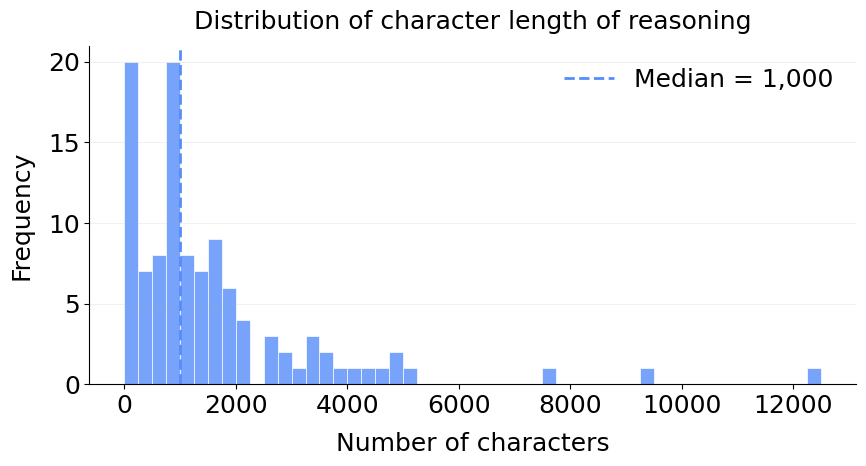

In [12]:
# plt.hist(df_reasoning["characters"], bins = 50)
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    df_reasoning["characters"].dropna(),
    bins=50,
    alpha=0.8,
    edgecolor="white",
    linewidth=0.6
)

median = df_reasoning["characters"].median()
ax.axvline(
    median,
    linestyle="--",
    linewidth=2,
    label=f"Median = {median:,.0f}"
)

ax.set_title("Distribution of character length of reasoning", pad=12)
ax.set_xlabel("Number of characters")
ax.set_ylabel("Frequency")

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [13]:
df_all["model"].nunique()

247

In [16]:
df_all.columns

Index(['prompt', 'model', 'inventory', 'situation', 'rep', 'item', 'preamble',
       'postamble', 'options', 'timestamp', 'response', 'usage', 'reasoning',
       'dimension', 'key', 'score', 'cost'],
      dtype='str')

In [14]:
df_A.columns

Index(['model', 'inventory', 'item', 'situation', 'prompt', 'preamble',
       'postamble', 'options', 'timestamp', 'usage', 'reasoning', 'dimension',
       'key', 'response', 'score', 'score_std', 'item_id', 'item_col'],
      dtype='str')

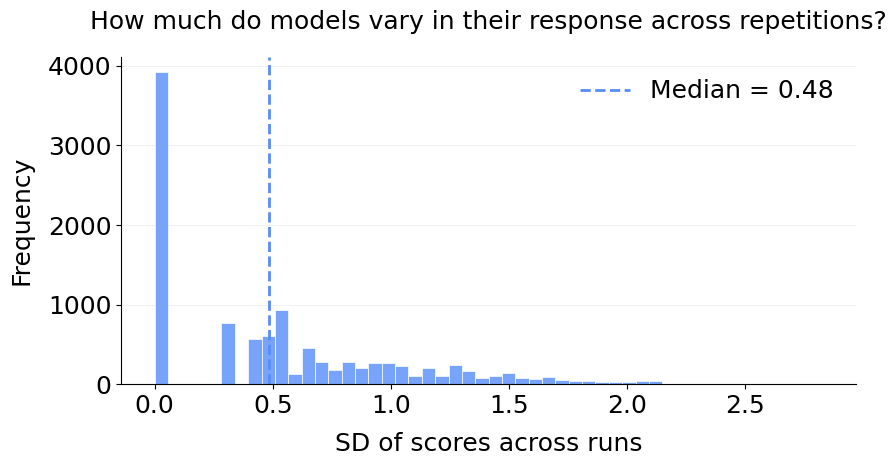

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    df_A["score_std"].dropna(),
    bins=50,
    alpha=0.8,
    edgecolor="white",
    linewidth=0.6
)

median = df_A["score_std"].median()
ax.axvline(
    median,
    linestyle="--",
    linewidth=2,
    label=f"Median = {median:.2f}"
)

ax.set_title("How much do models vary in their response across repetitions?", pad=20)
ax.set_xlabel("SD of scores across runs")
ax.set_ylabel("Frequency")

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)
plt.tight_layout()
plt.show()

/var/folders/tq/zy_cnh614c5d9k3yfc0_sfdr0000gn/T/ipykernel_24330/564434760.py:64: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skewness": skew(x, bias=False),


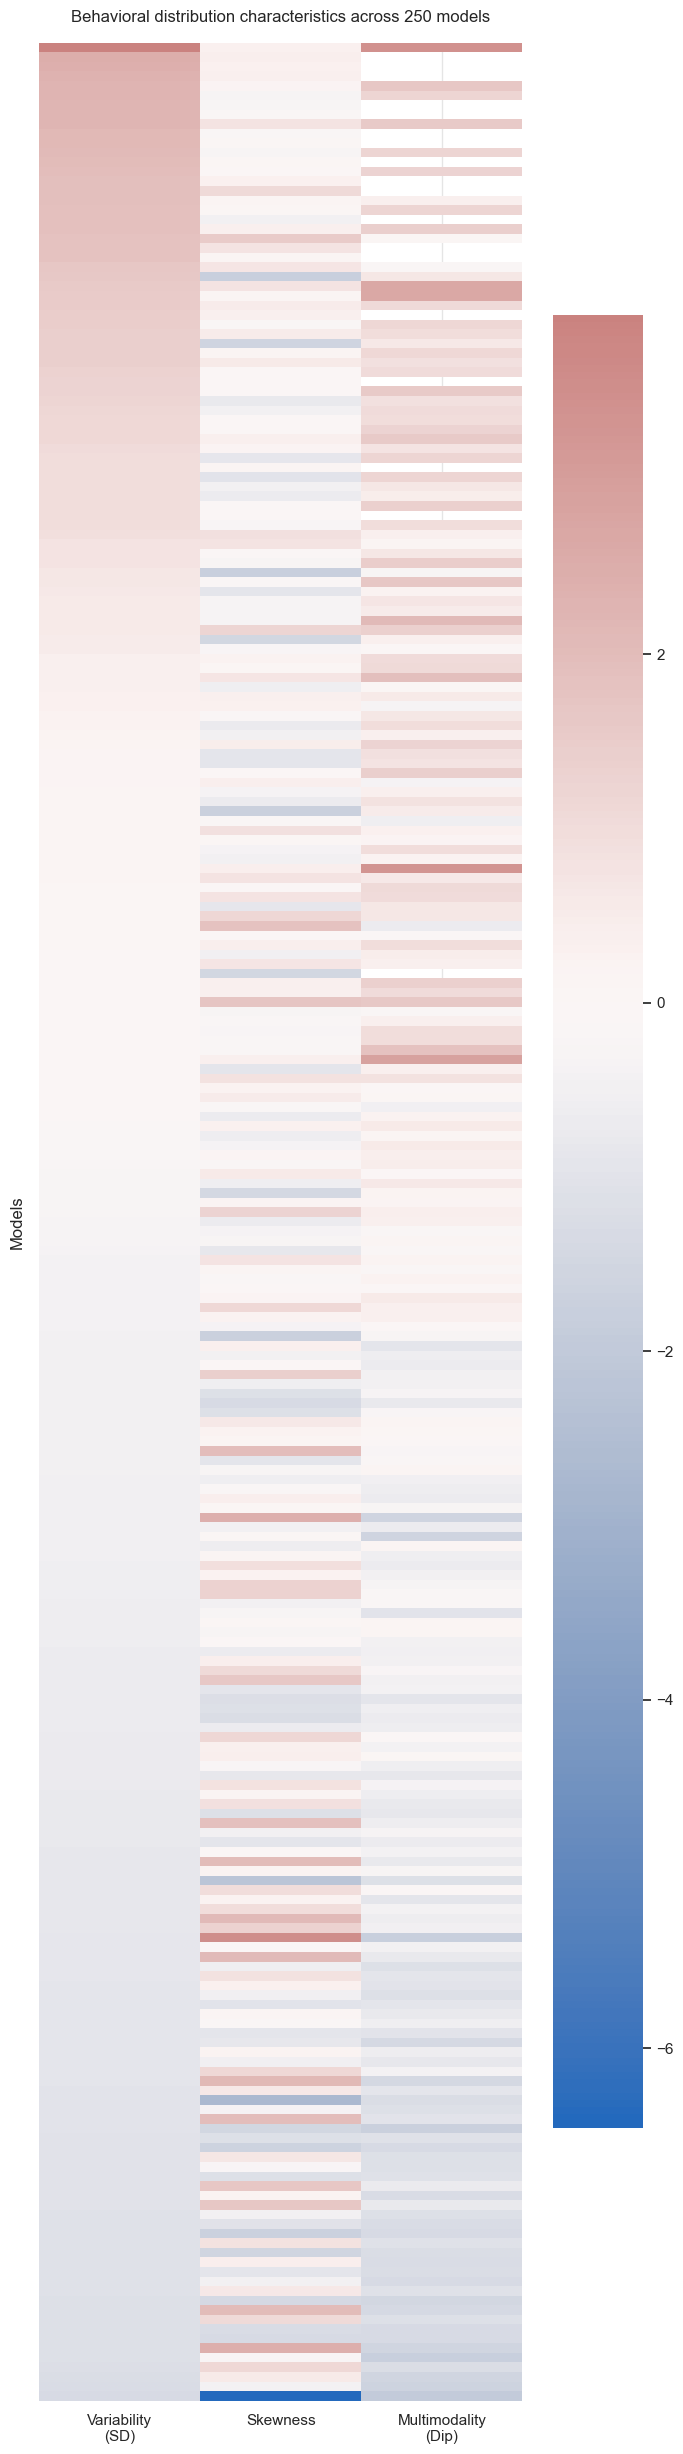

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kruskal, mannwhitneyu
from itertools import combinations
from statsmodels.stats.multitest import multipletests
from diptest import diptest


# ============================================================
# 1. PREPARE DATA
# ============================================================

df = df_all[
    ["model", "item", "rep", "score"]
].copy()

df["score"] = pd.to_numeric(df["score"], errors="coerce")

df = df.dropna(
    subset=["model", "item", "score"]
)


# ============================================================
# 2. DISTRIBUTIONAL STATISTICS
#
# Unit of analysis = model × item
# ============================================================

def dip_test_safe(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 10:
        return np.nan, np.nan

    return diptest(x)


stats = []

for (model, item), g in df.groupby(["model", "item"]):

    x = g["score"].values

    if len(x) < 2:
        continue

    dip, dip_p = dip_test_safe(x)

    stats.append({
        "model": model,
        "item": item,
        "n": len(x),

        # Dispersion
        "sd": np.std(x, ddof=1),
        "variance": np.var(x, ddof=1),

        # Shape
        "skewness": skew(x, bias=False),

        # Multimodality
        "dip": dip,
        "dip_p": dip_p,
    })


dist_stats = pd.DataFrame(stats)


# ============================================================
# 3. MODEL-LEVEL SUMMARY
#
# Each model now gets a small set of summary statistics.
# ============================================================

model_summary = (
    dist_stats
    .groupby("model")
    .agg(
        n_items=("item", "count"),

        # ----------------------------
        # Variability
        # ----------------------------
        mean_sd=("sd", "mean"),
        median_sd=("sd", "median"),

        mean_variance=("variance", "mean"),
        median_variance=("variance", "median"),

        # ----------------------------
        # Shape
        # ----------------------------
        mean_skewness=("skewness", "mean"),
        median_skewness=("skewness", "median"),

        # ----------------------------
        # Multimodality
        # ----------------------------
        mean_dip=("dip", "mean"),
        median_dip=("dip", "median"),

        proportion_dip_p05=(
            "dip_p",
            lambda x: np.mean(x < .05)
        ),
    )
    .reset_index()
)


# ============================================================
# 4. RANK MODELS FOR EACH DIMENSION
# ============================================================

model_summary["variability_rank"] = (
    model_summary["mean_sd"]
    .rank(ascending=False)
)

model_summary["skew_rank"] = (
    model_summary["mean_skewness"]
    .rank(ascending=False)
)

model_summary["multimodality_rank"] = (
    model_summary["mean_dip"]
    .rank(ascending=False)
)


# ============================================================
# 5. COMPACT 250-MODEL HEATMAP
#
# Each row = model
# Each column = one behavioral dimension
#
# This is much more readable than 250 boxplots.
# ============================================================

heatmap_data = (
    model_summary
    .set_index("model")[
        [
            "mean_sd",
            "mean_skewness",
            "mean_dip"
        ]
    ]
    .copy()
)

# Standardize each column so the three measures
# are visually comparable.

heatmap_z = (
    heatmap_data - heatmap_data.mean()
) / heatmap_data.std()

# Sort models by variability
heatmap_z = heatmap_z.sort_values(
    "mean_sd",
    ascending=False
)

fig, ax = plt.subplots(
    figsize=(7, max(10, len(heatmap_z) * 0.10))
)

sns.heatmap(
    heatmap_z,
    cmap="vlag",
    center=0,
    yticklabels=False,
    xticklabels=[
        "Variability\n(SD)",
        "Skewness",
        "Multimodality\n(Dip)"
    ],
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Models")
ax.set_title(
    "Behavioral distribution characteristics across 250 models",
    pad=15
)

plt.tight_layout()
plt.show()

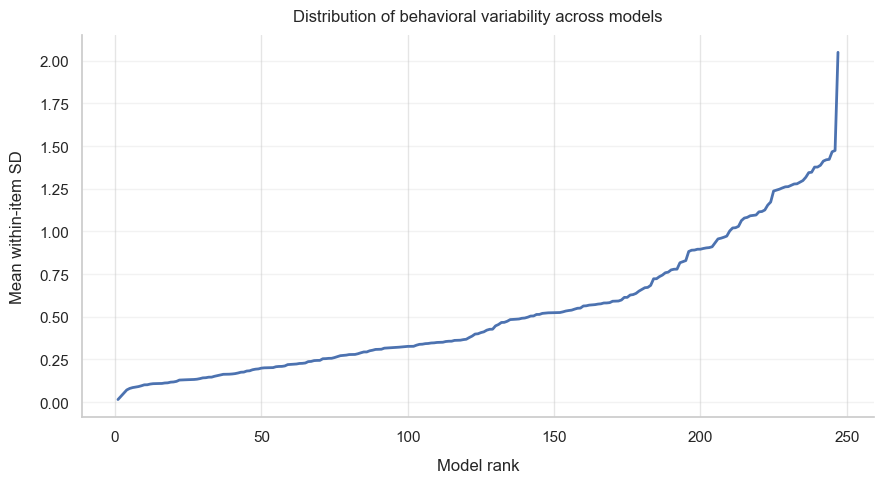

In [20]:
# ============================================================
# 6. RANK DISTRIBUTION OF MODEL VARIABILITY
# ============================================================

x = (
    model_summary["mean_sd"]
    .sort_values()
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    np.arange(1, len(x) + 1),
    x,
    linewidth=2
)

ax.set_xlabel("Model rank")
ax.set_ylabel("Mean within-item SD")
ax.set_title(
    "Distribution of behavioral variability across models"
)

ax.grid(axis="y", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

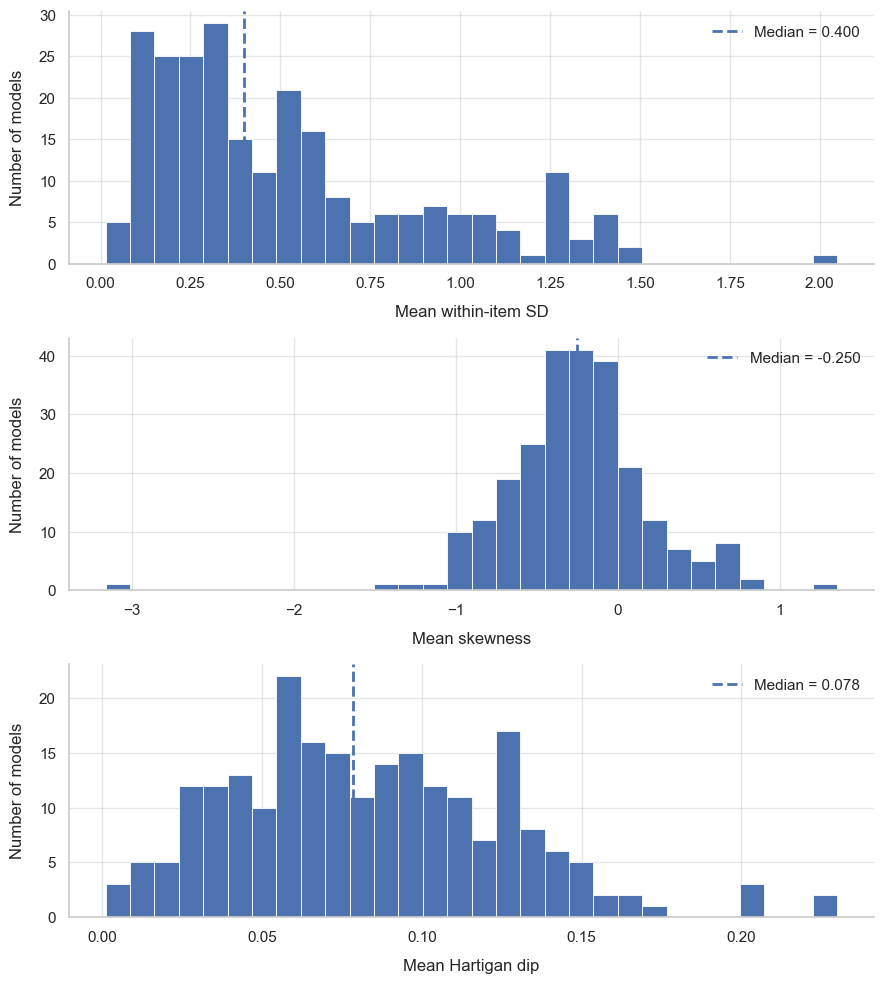

In [21]:
# ============================================================
# 9. DISTRIBUTION ACROSS MODELS
# ============================================================

fig, axes = plt.subplots(
    3, 1,
    figsize=(9, 10)
)

plots = [
    ("mean_sd", "Mean within-item SD"),
    ("mean_skewness", "Mean skewness"),
    ("mean_dip", "Mean Hartigan dip")
]

for ax, (col, xlabel) in zip(axes, plots):

    ax.hist(
        model_summary[col].dropna(),
        bins=30,
        edgecolor="white",
        linewidth=0.6
    )

    median = model_summary[col].median()

    ax.axvline(
        median,
        linestyle="--",
        linewidth=2,
        label=f"Median = {median:.3f}"
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of models")

    ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# Extreme models and their raw score distributions
# ============================================================

# 1. Identify the extreme models
highest_sd_model = (
    model_summary.loc[
        model_summary["mean_sd"].idxmax(),
        "model"
    ]
)

highest_skew_model = (
    model_summary.loc[
        model_summary["mean_skewness"].idxmax(),
        "model"
    ]
)

highest_multimod_model = (
    model_summary.loc[
        model_summary["mean_dip"].idxmax(),
        "model"
    ]
)

lowest_sd_model = (
    model_summary.loc[
        model_summary["mean_sd"].idxmin(),
        "model"
    ]
)

lowest_skew_model = (
    model_summary.loc[
        model_summary["mean_skewness"].idxmin(),
        "model"
    ]
)

lowest_multimod_model = (
    model_summary.loc[
        model_summary["mean_dip"].idxmin(),
        "model"
    ]
)

print("Highest variability:", highest_sd_model)
print("Highest skewness:", highest_skew_model)
print("Highest multimodality:", highest_multimod_model)
print("Lowest variability:", lowest_sd_model)
print("Lowest skewness:", lowest_skew_model)
print("Lowest multimodality:", lowest_multimod_model)

Highest variability: openrouter/morph/morph-v3-fast
Highest skewness: deepinfra/deepseek-ai/DeepSeek-R1-0528-Turbo
Highest multimodality: openrouter/morph/morph-v3-fast
Lowest variability: deepinfra/Qwen/Qwen3-30B-A3B
Lowest skewness: deepinfra/Qwen/Qwen3-30B-A3B
Lowest multimodality: deepinfra/Qwen/Qwen3-30B-A3B


In [26]:
import numpy as np
import pandas as pd
from scipy.stats import skew
from diptest import diptest

id_cols = ["model", "inventory", "item", "situation"]

stats = []

for keys, g in df_all.groupby(id_cols):
    model, inventory, item, situation = keys

    x = g["score"].dropna().values

    if len(x) < 2:
        continue

    dip, dip_p = diptest(x) if len(x) >= 10 else (np.nan, np.nan)

    stats.append({
        "model": model,
        "inventory": inventory,
        "item": item,
        "situation": situation,
        "n": len(x),

        # variability within the SAME item
        "sd": np.std(x, ddof=1),
        "variance": np.var(x, ddof=1),

        # shape within the SAME item
        "skewness": skew(x, bias=False),

        # multimodality within the SAME item
        "dip": dip,
        "dip_p": dip_p,
    })

item_stats = pd.DataFrame(stats)

/var/folders/tq/zy_cnh614c5d9k3yfc0_sfdr0000gn/T/ipykernel_24330/3836251248.py:32: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skewness": skew(x, bias=False),


In [28]:
model_summary = (
    item_stats
    .groupby("model")
    .agg(
        mean_sd=("sd", "mean"),
        median_sd=("sd", "median"),

        mean_variance=("variance", "mean"),
        median_variance=("variance", "median"),

        mean_skewness=("skewness", "mean"),
        median_skewness=("skewness", "median"),

        mean_dip=("dip", "mean"),
        median_dip=("dip", "median"),
    )
    .reset_index()
)

In [29]:
model_summary

,model,mean_sd,median_sd,mean_variance,median_variance,mean_skewness,median_skewness,mean_dip,median_dip
0,Qwen/Qwen3-0.6B-Base,1.346789,1.414214,2.217500,2.000000,-0.328878,-0.199735,NaN,NaN
1,Qwen/Qwen3-14B-Base,1.019843,1.002412,1.134497,1.004960,-0.295496,-0.192445,0.150000,0.150
2,Qwen/Qwen3-30B-A3B-Base,1.021549,0.995516,1.328463,0.991071,-0.257036,0.000000,NaN,NaN
3,Qwen/Qwen3-8B-Base,1.116404,1.122013,1.355265,1.258929,-0.171876,-0.071454,0.200000,0.200
4,Qwen/Qwen3.5-35B-A3B-Base,1.260988,1.414214,1.842735,2.000000,-0.447710,-0.165635,NaN,NaN
...,...,...,...,...,...,...,...,...,...
242,xai/grok-4-1-fast-non-reasoning,0.174553,0.000000,0.194192,0.000000,-0.488245,0.000000,0.032955,0.000
243,xai/grok-4-1-fast-reasoning,0.128592,0.000000,0.107323,0.000000,-0.144830,-0.282699,0.028409,0.000
244,xai/grok-4-fast,0.090431,0.000000,0.051768,0.000000,-0.818994,-1.406940,0.025000,0.000
245,xai/grok-4.20,0.255844,0.316228,0.125000,0.100000,-0.758724,-0.484123,0.057955,0.050


## Variance

In [36]:
highest_sd_model = (
    model_summary
    .loc[model_summary["mean_sd"].idxmax(), "model"]
)

highest_sd_value = (
    model_summary
    .loc[model_summary["mean_sd"].idxmax(), "mean_sd"]
)

lowest_sd_model = (
    model_summary.loc[model_summary["mean_sd"].idxmin(), "model"]
)

lowest_sd_value = (
    model_summary.loc[model_summary["mean_sd"].idxmin(), "mean_sd"]
)

print("Highest variability model:", highest_sd_model)
print("Mean within-item SD:", highest_sd_value)
print("\nLowest variability model:", lowest_sd_model)
print("Mean within-item SD:", lowest_sd_value)

Highest variability model: openrouter/morph/morph-v3-fast
Mean within-item SD: 2.0493080532277728

Lowest variability model: deepinfra/Qwen/Qwen3-30B-A3B
Mean within-item SD: 0.014373989364401724


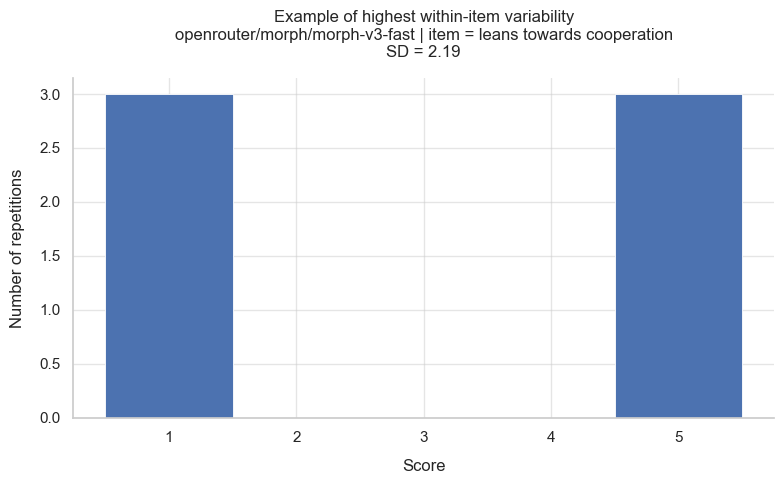

In [34]:
highest_sd_item = (
    item_stats[
        item_stats["model"] == highest_sd_model
    ]
    .sort_values("sd", ascending=False)
    .iloc[0]
)

example = df_all[
    (df_all["model"] == highest_sd_model) &
    (df_all["inventory"] == highest_sd_item["inventory"]) &
    (df_all["item"] == highest_sd_item["item"]) &
    (df_all["situation"] == highest_sd_item["situation"])
].copy()

x = example["score"].dropna()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    x,
    bins=np.arange(x.min() - 0.5, x.max() + 1.5),
    edgecolor="white",
    linewidth=0.6
)

ax.set_title(
    f"Example of highest within-item variability\n"
    f"{highest_sd_model} | item = {highest_sd_item['item']}\n"
    f"SD = {highest_sd_item['sd']:.2f}",
    pad=15
)

ax.set_xlabel("Score")
ax.set_ylabel("Number of repetitions")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

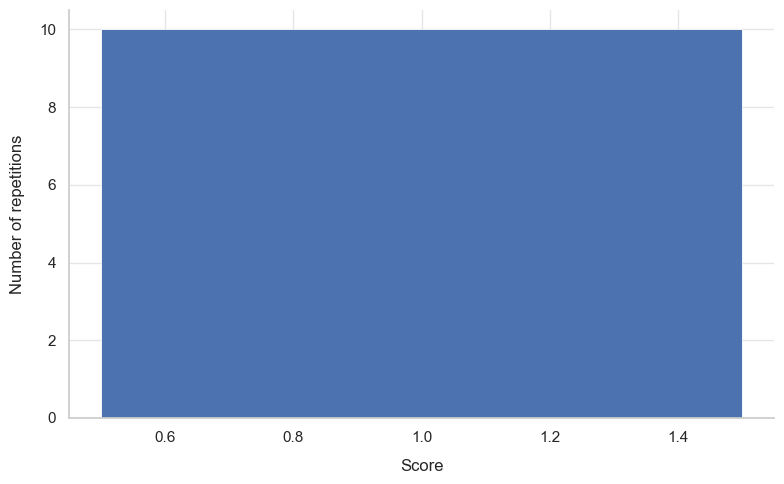

In [45]:
lowest_sd_item = (
    item_stats[
        item_stats["model"] == lowest_sd_model
    ]
    .sort_values("sd", ascending=True)
    .iloc[0]
)

example = df_all[
    (df_all["model"] == lowest_sd_model) &
    (df_all["inventory"] == lowest_sd_item["inventory"]) &
    (df_all["item"] == lowest_sd_item["item"]) &
    (df_all["situation"] == lowest_sd_item["situation"])
].copy()

x = example["score"].dropna()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    x,
    bins=np.arange(x.min() - 0.5, x.max() + 1.5),
    edgecolor="white",
    linewidth=0.6
)


ax.set_xlabel("Score")
ax.set_ylabel("Number of repetitions")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Skewness

In [39]:
highest_skew_model = (
    model_summary
    .loc[model_summary["mean_skewness"].idxmax(), "model"]
)

lowest_skew_model = (
    model_summary
    .loc[model_summary["mean_skewness"].idxmin(), "model"]
)

print(highest_skew_model)
print("\n", lowest_skew_model)

deepinfra/deepseek-ai/DeepSeek-R1-0528-Turbo

 deepinfra/Qwen/Qwen3-30B-A3B


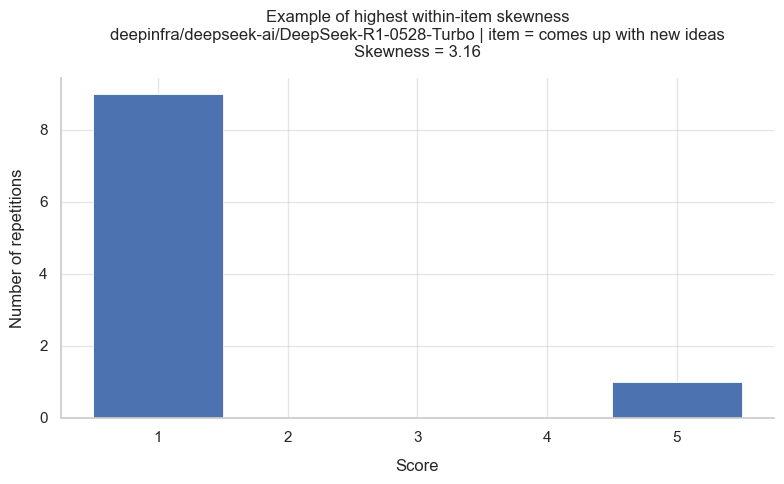

In [41]:
highest_skew_item = (
    item_stats[
        item_stats["model"] == highest_skew_model
    ]
    .sort_values("skewness", ascending=False)
    .iloc[0]
)

example = df_all[
    (df_all["model"] == highest_skew_model) &
    (df_all["inventory"] == highest_skew_item["inventory"]) &
    (df_all["item"] == highest_skew_item["item"]) &
    (df_all["situation"] == highest_skew_item["situation"])
]

x = example["score"].dropna()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    x,
    bins=np.arange(x.min() - 0.5, x.max() + 1.5),
    edgecolor="white",
    linewidth=0.6
)

ax.set_title(
    f"Example of highest within-item skewness\n"
    f"{highest_skew_model} | item = {highest_skew_item['item']}\n"
    f"Skewness = {highest_skew_item['skewness']:.2f}",
    pad=15
)

ax.set_xlabel("Score")
ax.set_ylabel("Number of repetitions")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

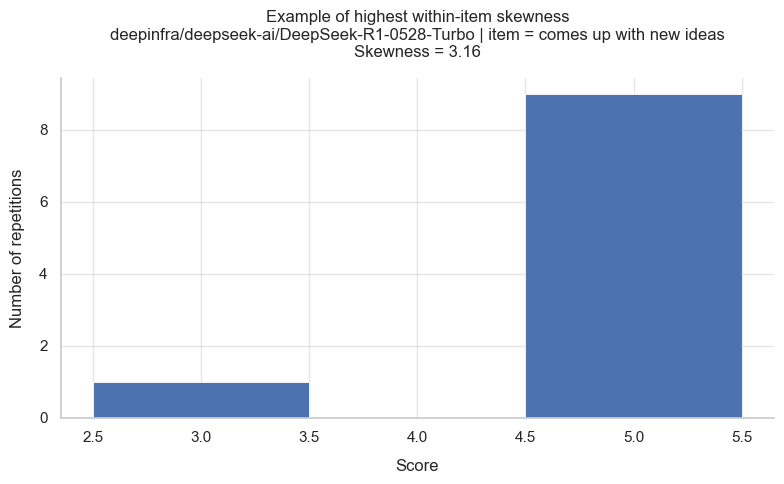

In [43]:
lowest_skew_item = (
    item_stats[
        item_stats["model"] == lowest_skew_model
    ]
    .sort_values("skewness", ascending=True)
    .iloc[0]
)

example = df_all[
    (df_all["model"] == lowest_skew_model) &
    (df_all["inventory"] == lowest_skew_item["inventory"]) &
    (df_all["item"] == lowest_skew_item["item"]) &
    (df_all["situation"] == lowest_skew_item["situation"])
]

x = example["score"].dropna()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    x,
    bins=np.arange(x.min() - 0.5, x.max() + 1.5),
    edgecolor="white",
    linewidth=0.6
)

ax.set_title(
    f"Example of highest within-item skewness\n"
    f"{highest_skew_model} | item = {highest_skew_item['item']}\n"
    f"Skewness = {highest_skew_item['skewness']:.2f}",
    pad=15
)

ax.set_xlabel("Score")
ax.set_ylabel("Number of repetitions")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [46]:
df_all[df_all["model"] == "deepinfra/Qwen/Qwen3-30B-A3B"]

,prompt,model,inventory,situation,rep,item,preamble,postamble,options,timestamp,response,usage,reasoning,dimension,key,score,cost
38350,Here is a characteristic that may or may not a...,deepinfra/Qwen/Qwen3-30B-A3B,bfi-llm,baseline,0,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260510,1.0,"{'total_tokens': 517, 'prompt_tokens': 130, 'c...","<think>\nOkay, the user is asking me to rate h...",Neuroticism,+,1.0,0.000123
38351,Here is a characteristic that may or may not a...,deepinfra/Qwen/Qwen3-30B-A3B,bfi-llm,baseline,1,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260510,1.0,"{'total_tokens': 471, 'prompt_tokens': 130, 'c...","<think>\nOkay, let's tackle this query. The us...",Neuroticism,+,1.0,0.000109
38352,Here is a characteristic that may or may not a...,deepinfra/Qwen/Qwen3-30B-A3B,bfi-llm,baseline,2,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260510,1.0,"{'total_tokens': 425, 'prompt_tokens': 130, 'c...","<think>\nOkay, the user is asking me to rate m...",Neuroticism,+,1.0,0.000096
38353,Here is a characteristic that may or may not a...,deepinfra/Qwen/Qwen3-30B-A3B,bfi-llm,baseline,3,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260510,1.0,"{'total_tokens': 895, 'prompt_tokens': 130, 'c...","<think>\nOkay, the user is asking me to rate m...",Neuroticism,+,1.0,0.000232
38354,Here is a characteristic that may or may not a...,deepinfra/Qwen/Qwen3-30B-A3B,bfi-llm,baseline,4,becomes hesitant or erratic when faced with di...,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n1 = Disagree strongly \n2 = Disagree a littl...,20260510,1.0,"{'total_tokens': 446, 'prompt_tokens': 130, 'c...","<think>\nOkay, the user is asking me to rate m...",Neuroticism,+,1.0,0.000102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38785,Here is a characteristic that may or may not a...,deepinfra/Qwen/Qwen3-30B-A3B,bfi-llm,baseline,0,uses imaginative examples,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n5 = Agree strongly \n4 = Agree a little \n3 ...,20260510,1.0,"{'total_tokens': 767, 'prompt_tokens': 125, 'c...","<think>\nOkay, the user is asking me to rate h...",Openness,+,1.0,0.000196
38786,Here is a characteristic that may or may not a...,deepinfra/Qwen/Qwen3-30B-A3B,bfi-llm,baseline,1,uses imaginative examples,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n5 = Agree strongly \n4 = Agree a little \n3 ...,20260510,1.0,"{'total_tokens': 481, 'prompt_tokens': 125, 'c...","<think>\nOkay, the user is asking me to rate h...",Openness,+,1.0,0.000113
38787,Here is a characteristic that may or may not a...,deepinfra/Qwen/Qwen3-30B-A3B,bfi-llm,baseline,2,uses imaginative examples,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n5 = Agree strongly \n4 = Agree a little \n3 ...,20260510,1.0,"{'total_tokens': 780, 'prompt_tokens': 125, 'c...","<think>\nOkay, the user wants me to rate how m...",Openness,+,1.0,0.000200
38788,Here is a characteristic that may or may not a...,deepinfra/Qwen/Qwen3-30B-A3B,bfi-llm,baseline,3,uses imaginative examples,Here is a characteristic that may or may not a...,\nAnswer only with a number between 1 and 5. S...,\n5 = Agree strongly \n4 = Agree a little \n3 ...,20260510,1.0,"{

In [49]:
df_bench = pd.read_parquet(
    "hf://datasets/OpenEvals/leaderboard-data/data/train-00000-of-00001.parquet"
)

df_bench

,model_id,model_name,provider,model_type,parameters_billions,license,context_window,modality,architecture,aime2026_score,...,hle_score,hmmt2026_score,mmluPro_score,olmOcr_score,swePro_score,sweVerified_score,terminalBench_score,aggregate_score,coverage_count,coverage_percent
0,meta-llama-llama-3.1-405b,meta-llama/Llama-3.1-405B,meta-llama,open,405.9,Unknown,0,text,Transformer,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.80,1,9.1
1,microsoft-phi-3-medium-4k-instruct,microsoft/Phi-3-medium-4k-instruct,microsoft,open,14.0,Unknown,0,text,Transformer,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.00,1,9.1
2,qwen-qwen2-72b,Qwen/Qwen2-72B,Qwen,open,72.7,Unknown,0,text,Transformer,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.50,1,9.1
3,deepseek-ai-deepseek-v3,deepseek-ai/DeepSeek-V3,deepseek-ai,open,684.5,Unknown,0,text,Transformer,NaN,...,NaN,NaN,64.4,NaN,NaN,NaN,NaN,76.85,2,18.2
4,microsoft-phi-3.5-mini-instruct,microsoft/Phi-3.5-mini-instruct,microsoft,open,3.8,Unknown,0,text,Transformer,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.20,1,9.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,qwen-qwen3-235b-a22b,Qwen/Qwen3-235B-A22B,Qwen,open,235.1,Unknown,0,text,Transformer,NaN,...,NaN,NaN,NaN,NaN,21.41,NaN,NaN,21.41,1,9.1
101,google-gemma-3-27b-it,google/gemma-3-27b-it,google,open,27.4,Unknown,0,text,Transformer,NaN,...,NaN,NaN,NaN,NaN,11.38,NaN,NaN,11.38,1,9.1
102,meta-llama-llama-3.1-405b-instruct,meta-llama/Llama-3.1-405B-Instruct,meta-llama,open,405.9,Unknown,0,text,Transformer,NaN,...,NaN,NaN,NaN,NaN,11.18,NaN,NaN,11.18,1,9.1
103,meta-llama-llama-4-maverick-17b-128e-instruct,meta-llama/Llama-4-Maverick-17B-128E-Instruct,meta-llama,open,401.6,Unknown,0,text,Transformer,NaN,...,NaN,NaN,NaN,NaN,5.24,NaN,NaN,5.24,1,9.1


In [52]:
benchmark_cols = [
    "aime2026_score",
    "evasionBench_score",
    "gpqa_score",
    "gsm8k_score",
    "hle_score",
    "hmmt2026_score",
    "mmluPro_score",
    "olmOcr_score",
    "swePro_score",
    "sweVerified_score",
    "terminalBench_score",
]

df_bench = df_bench[df_bench["coverage_count"] > 1].copy()

# Average performance across available benchmarks
df_bench["benchmark_mean"] = df_bench[benchmark_cols].mean(
    axis=1,
    skipna=True
)

# SD across the available benchmark scores
df_bench["benchmark_sd"] = df_bench[benchmark_cols].std(
    axis=1,
    skipna=True,
    ddof=1
)

df_bench[[
    "model_name",
    "coverage_count",
    "benchmark_mean",
    "benchmark_sd"
]].sort_values("benchmark_sd", ascending=False)

,model_name,coverage_count,benchmark_mean,benchmark_sd
47,Nanbeige/Nanbeige4.1-3B,2,48.200000,50.346003
37,nvidia/NVIDIA-Nemotron-3-Nano-30B-A3B-FP8,2,44.150000,48.012550
35,nvidia/NVIDIA-Nemotron-3-Nano-30B-A3B-BF16,2,46.900000,44.406306
41,tiiuae/Falcon-H1R-7B,2,41.600000,43.133514
25,LGAI-EXAONE/K-EXAONE-236B-A23B,3,58.833333,39.243641
49,meituan-longcat/LongCat-Flash-Thinking-2601,2,52.850000,39.103005
33,nvidia/Nemotron-Cascade-2-30B-A3B,3,57.866667,34.834514
29,MiniMaxAI/MiniMax-M2,4,48.475000,32.646120
50,zai-org/GLM-4.7-Flash,3,49.600000,31.516345
46,MiniMaxAI/MiniMax-M2.5,4,58.950000,29.153559


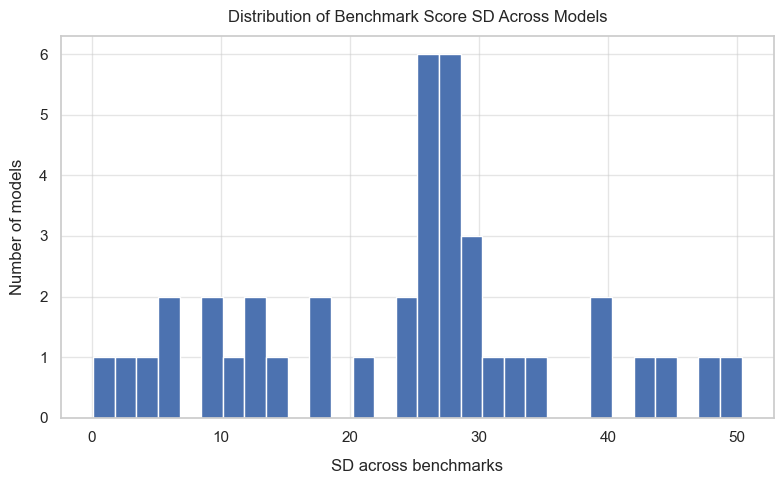

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    df_bench["benchmark_sd"].dropna(),
    bins=30
)

plt.xlabel("SD across benchmarks")
plt.ylabel("Number of models")
plt.title("Distribution of Benchmark Score SD Across Models")
plt.tight_layout()
plt.show()

In [59]:
df_B.head()

dimension,model,Openness,Conscientiousness,Extraversion,Agreeableness,Neuroticism
0,Qwen/Qwen3-0.6B-Base,3.357143,3.193548,2.892857,3.634146,3.954545
1,Qwen/Qwen3-14B-Base,3.420455,3.843373,3.539474,3.722892,2.357143
2,Qwen/Qwen3-30B-A3B-Base,3.562500,3.378378,4.062500,3.476190,2.500000
3,Qwen/Qwen3-8B-Base,3.184211,3.536232,3.127451,3.728571,2.592593
4,Qwen/Qwen3.5-35B-A3B-Base,3.583333,3.000000,3.965517,3.485714,2.538462
